<h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Introduction</h1>

<img src="https://i.ytimg.com/vi/fnXaB75Fd58/maxresdefault.jpg">

* Welcome to my notebook for the Kaggle Playground Series competition, "[Binary Classification of Machine Failures](https://www.kaggle.com/competitions/playground-series-s3e17/overview)." In this competition, our goal is to analyze and model a machine failure dataset to predict machine failures accurately. The dataset provided for this competition, both in the training and test sets, was generated from a deep learning model trained on [Machine Failure Predictions](https://www.kaggle.com/datasets/dineshmanikanta/machine-failure-predictions). While the feature distributions in this dataset are similar to the original, they are not identical. However, we are encouraged to use the original dataset as part of our analysis to explore differences and assess whether incorporating it in training improves model performance.

* The evaluation metric for this competition is the area under the [Receiver Operating Characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) (ROC) curve. We will be assessed based on how well our predicted probabilities align with the observed target values.

* The dataset contains a variety of features that provide insights into machine performance, including air temperature, process temperature, rotational speed, torque, tool wear time, and different types of machine failures.

* Throughout this notebook, we will follow a systematic approach to analyze the dataset, understand the features, perform exploratory data analysis, preprocess the data, and build predictive models. Our primary focus will be on developing a robust binary classification model that accurately predicts machine failures.

* Let's dive in and explore the data to gain valuable insights and build an effective machine learning solution for this problem.

# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left"> Import</h1>

In [1]:
# Misc
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from copy import deepcopy
from functools import partial
from itertools import combinations
import random
import gc

# Import sklearn classes for model selection, cross validation, and performance evaluation
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from category_encoders import OrdinalEncoder, CountEncoder, CatBoostEncoder, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer, LabelEncoder # OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.under_sampling import RandomUnderSampler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.decomposition import PCA, NMF
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector

# Import libraries for Hypertuning
import optuna

# Import libraries for gradient boosting
import lightgbm as lgb
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.svm import NuSVC, SVC
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from catboost import CatBoost, CatBoostRegressor, CatBoostClassifier
from catboost import Pool

# Useful line of code to set the display option so we could see all the columns in pd dataframe
pd.set_option('display.max_columns', None)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Check Dataset </h1>

**Data Description:**

Features are explained as follows:

* *ID (Unique Device Identifier)* is an identification code that is unique to each device. The codes range from 1 to 10,000.
* *Product ID* is an identification code for each product. This ID is a combination of letters and numbers.
* *Type* is the classification of the product or device into three categories: Low, Medium, and High. The proportions of these types in the dataset are as follows: Low 50%, Medium 30%, and High 20%.
* *Air temperature [K]* represents the temperature of the air, measured in Kelvin units.
* *Process temperature [K]* indicates the temperature during the production process, measured in Kelvin units.
* *Rotational speed [rpm]* refers to the number of revolutions per minute. It is calculated based on a power of 2860 W and is subject to normally distributed noise.
* *Torque [Nm]* measures the force that causes an object to rotate, expressed in Newton-meters (Nm). The torque values are normally distributed around 40 Nm and do not include negative values.
* *Tool wear [min]* represents the time it takes for production tools to erode or become damaged due to regular wear and tear caused by cutting operations.

Features indicating the area or cause of failure are as follows:

* *TWF (Tool Wear Failure)*: Indicates industrial tool failure, leading to the need for equipment change and defective products.
* *HDF (Heat Dissipation Failure)*: Indicates failure in heat dissipation during the production process.
* *PWF (Power Failure)*: Indicates that the supplied power was not suitable for the production process, resulting in a failure.
* *OSF (Overstain Failure)*: Indicates failure due to product overstains, which may occur as a result of high load and tension during production.
* *RNF (Random Failure)*: Indicates that a random error causes the failure.

In [2]:
df_train = pd.read_csv("/kaggle/input/playground-series-s3e17/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e17/test.csv")
sample_submission = pd.read_csv("/kaggle/input/playground-series-s3e17/sample_submission.csv")
original = pd.read_csv("/kaggle/input/machine-failure-predictions/machine failure.csv")

print(f'Data Successfully Loaded \n')

target_col = 'Machine failure'

num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
binary_cols = [
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]
cat_cols = df_test.select_dtypes(include=['object']).columns.tolist()

df_train['is_generated'] = 1
df_test['is_generated'] = 1
original['is_generated'] = 0

print(f'[INFO] Shapes:'
      f'\n original: {original.shape}'
      f'\n train: {df_train.shape}'
      f'\n test: {df_test.shape}\n')

print(f'[INFO] Any missing values:'
      f'\n original: {original.isna().any().any()}'
      f'\n train: {df_train.isna().any().any()}'
      f'\n test: {df_test.isna().any().any()}')

Data Successfully Loaded 

[INFO] Shapes:
 original: (10000, 15)
 train: (136429, 15)
 test: (90954, 14)

[INFO] Any missing values:
 original: False
 train: False
 test: False


In [3]:
df_train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,is_generated
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,1
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,1
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,1
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,1
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,1


In [4]:
original.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,is_generated
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0


In [5]:
df_train.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,is_generated
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.0
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258,1.0
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461,0.0
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


In [6]:
original.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,is_generated
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.0
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,0.0
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,0.0
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.0


# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">EDA </h1>

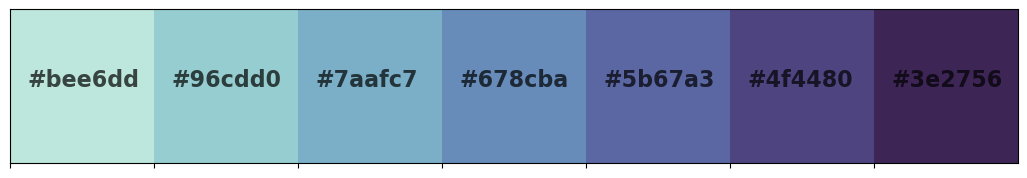

In [7]:
# Create palette

my_palette = sns.cubehelix_palette(n_colors = 7, start=.46, rot=-.45, dark = .2, hue=0.95)
sns.palplot(my_palette)
plt.gcf().set_size_inches(13,2)

for idx,values in enumerate(my_palette.as_hex()):
    plt.text(idx-0.375,0, my_palette.as_hex()[idx],{'font': "Courier New", 'size':16, 'weight':'bold','color':'black'}, alpha =0.7)
plt.gcf().set_facecolor('white')

plt.show()

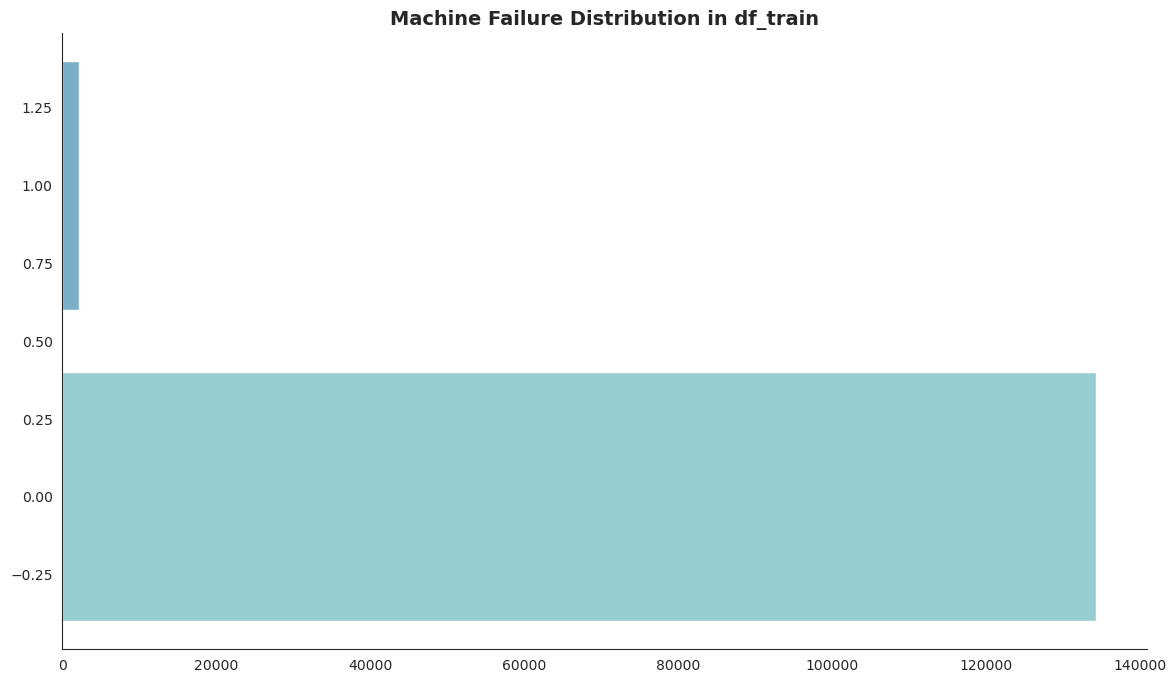

In [8]:
# create figure and set style with white background
plt.figure(figsize = (14, 8))
sns.set_style('white')

# set colors
colors = my_palette

# plot
plt.barh(df_train[target_col].value_counts().index,
        df_train[target_col].value_counts(),
        color = colors[1:3])

# set title
plt.title('Machine Failure Distribution in df_train', fontsize = 14, fontweight = 'bold')

# remove spines from plot
sns.despine()

# display all open figures
plt.show()

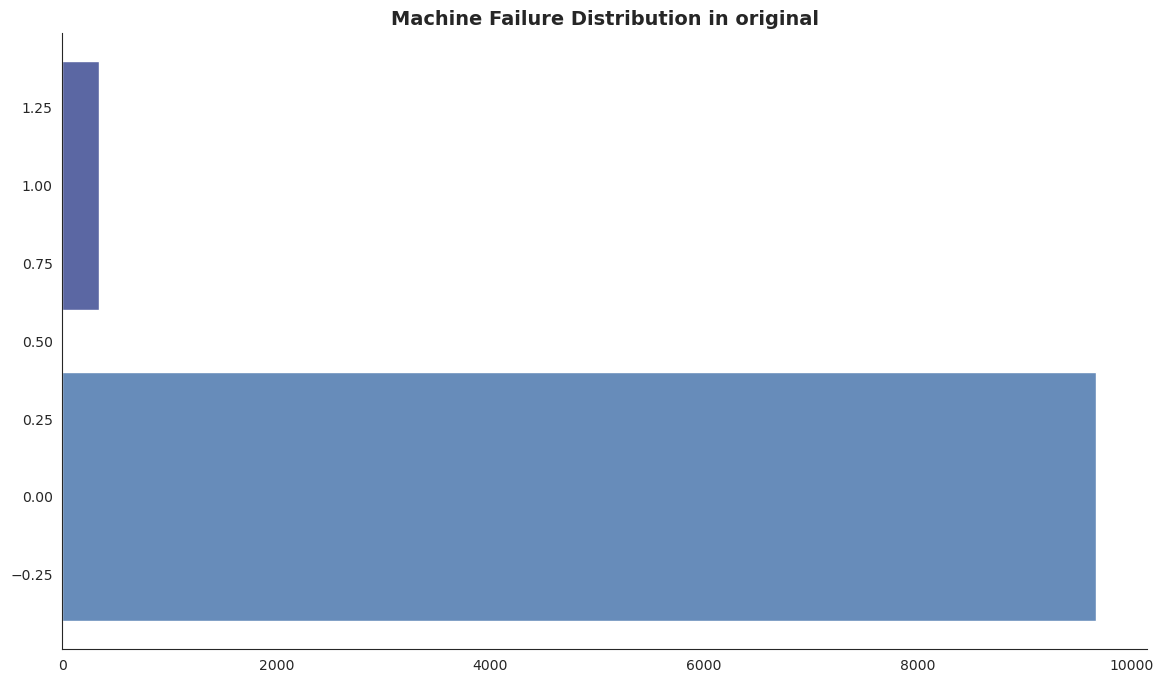

In [9]:
# create figure and set style with white background
plt.figure(figsize = (14, 8))
sns.set_style('white')

# set colors
colors = my_palette

# plot
plt.barh(original[target_col].value_counts().index,
        original[target_col].value_counts(),
        color = colors[3:5])

# set title
plt.title('Machine Failure Distribution in original', fontsize = 14, fontweight = 'bold')

# remove spines from plot
sns.despine()

# display all open figures
plt.show()

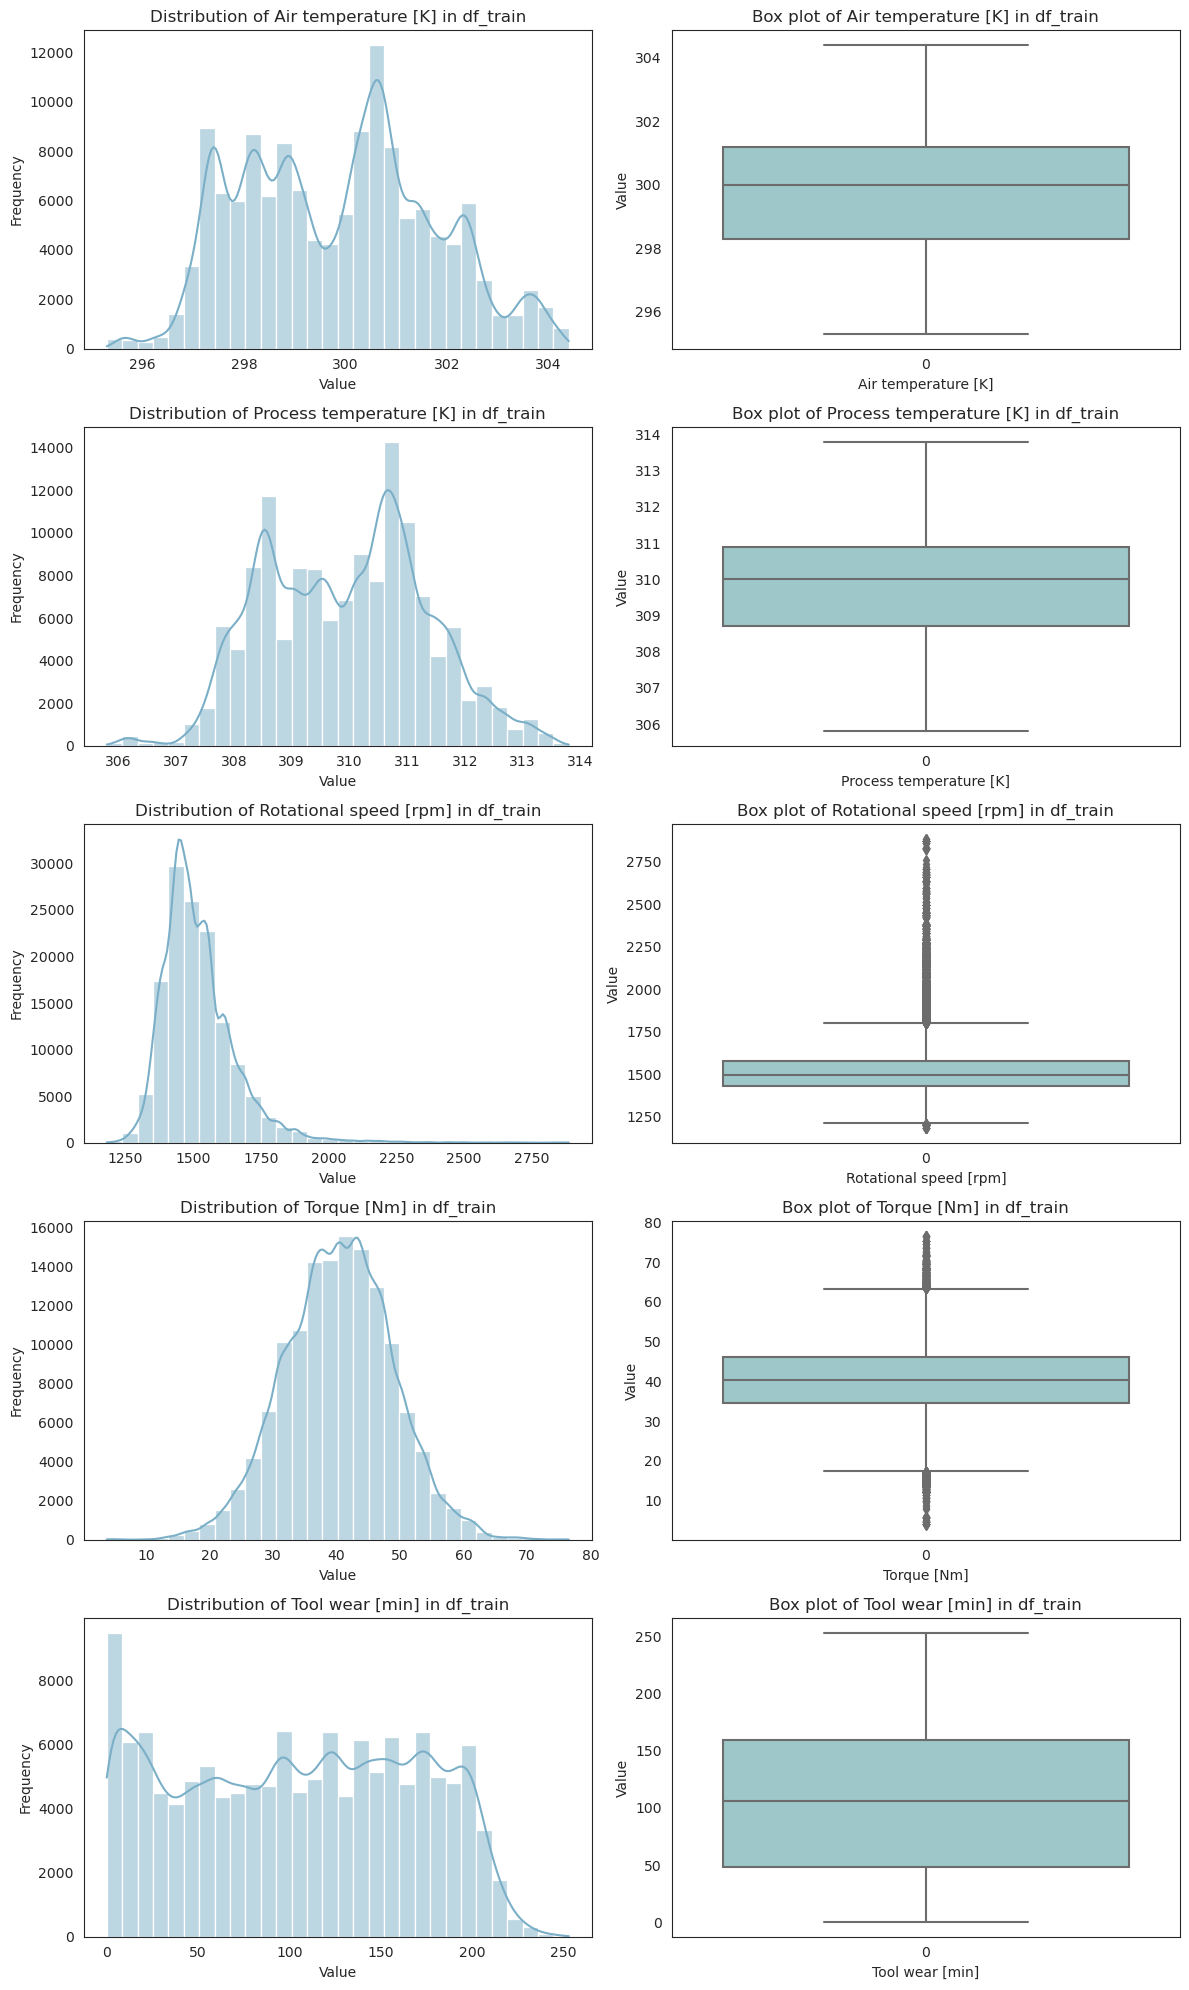

In [10]:
# Check basic statistics for numerical columns in train data
numerical_columns = num_cols

# Create subplots
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(12, 20))

# Plot the histograms and box plots
for i, column in enumerate(numerical_columns):
    # Histogram
    sns.histplot(df_train[column], bins=30, kde=True, ax=axes[i, 0], color = my_palette[2])
    axes[i, 0].set_title(f'Distribution of {column} in df_train')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(df_train[column], ax=axes[i, 1], color = my_palette[1])
    axes[i, 1].set_title(f'Box plot of {column} in df_train')
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

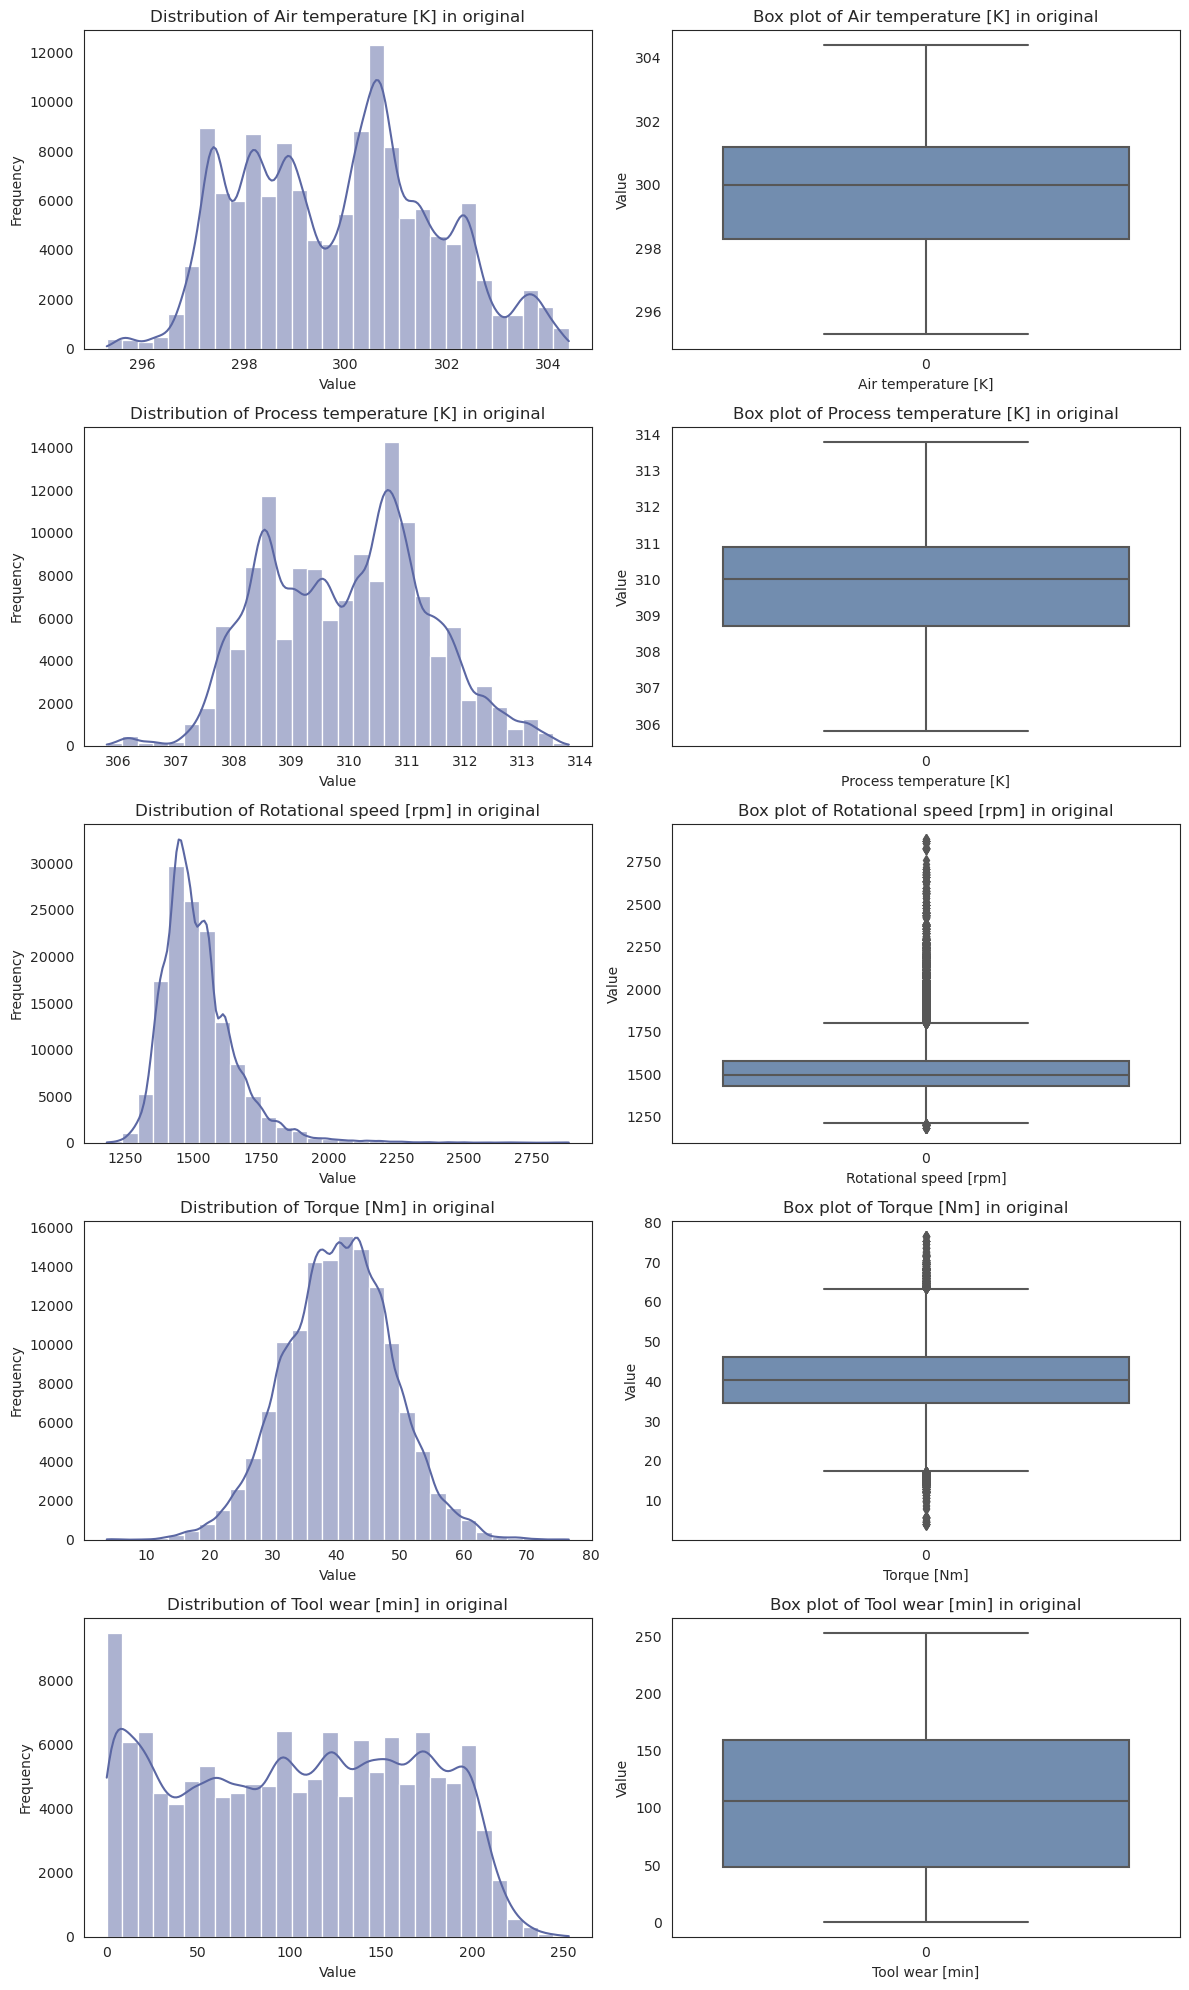

In [11]:
# Check basic statistics for numerical columns in original data
numerical_columns = num_cols

# Create subplots
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(12, 20))

# Plot the histograms and box plots
for i, column in enumerate(numerical_columns):
    # Histogram
    sns.histplot(df_train[column], bins=30, kde=True, ax=axes[i, 0], color = my_palette[4])
    axes[i, 0].set_title(f'Distribution of {column} in original')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(df_train[column], ax=axes[i, 1], color = my_palette[3])
    axes[i, 1].set_title(f'Box plot of {column} in original')
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

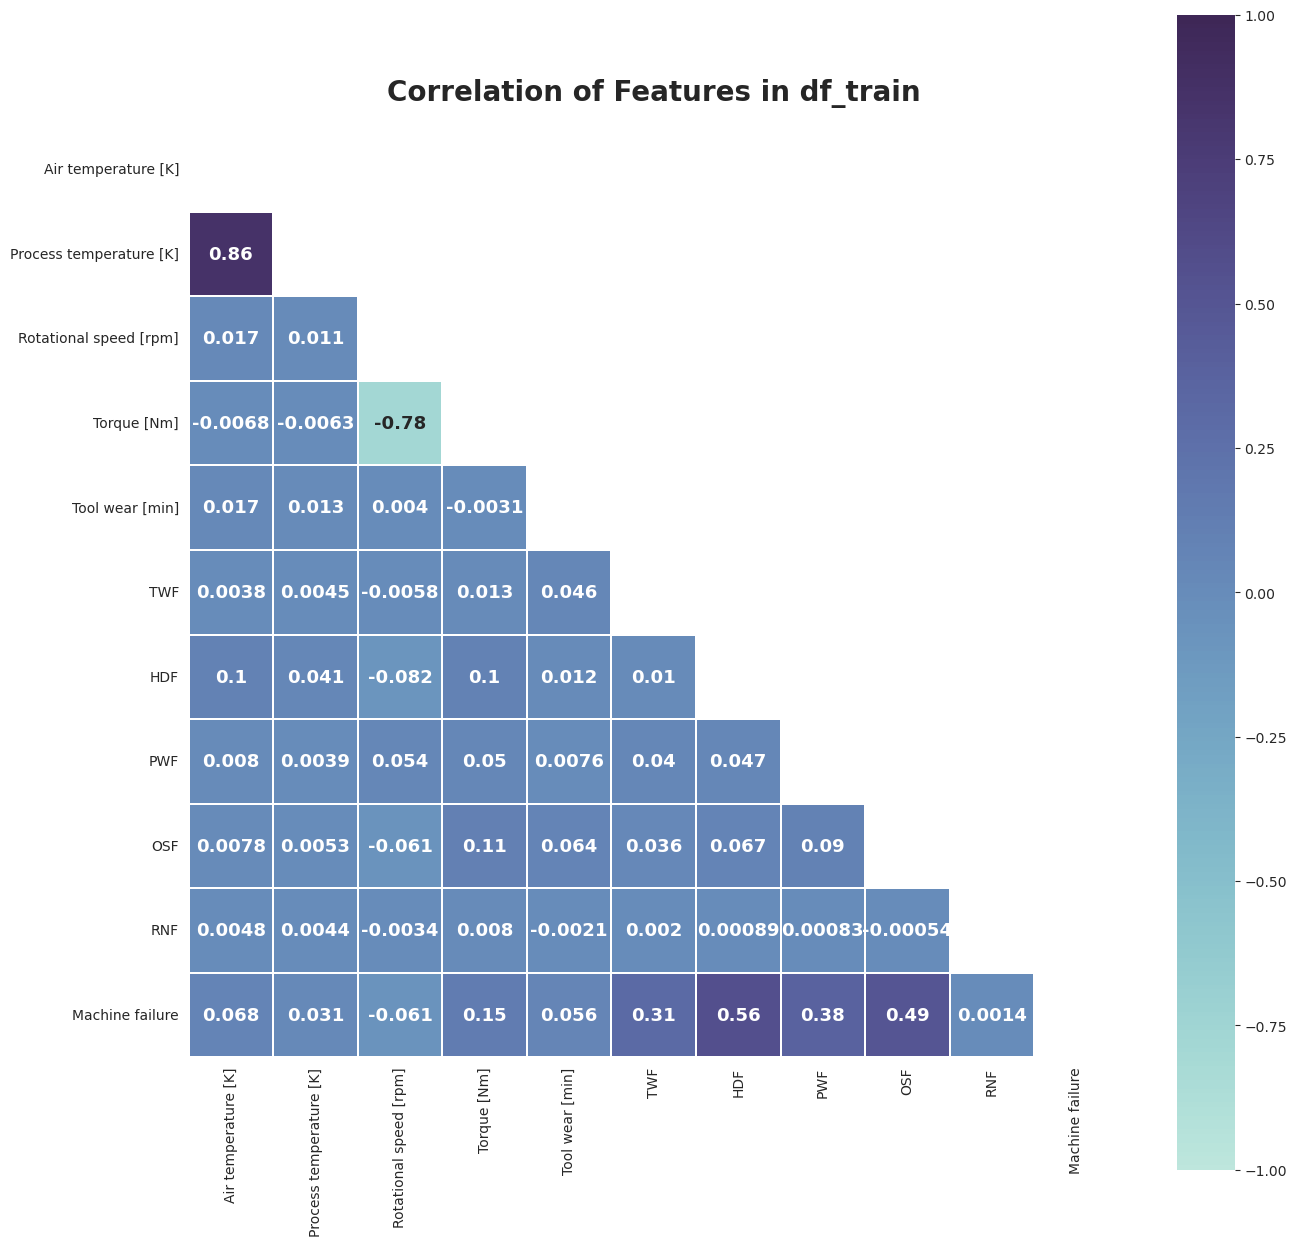

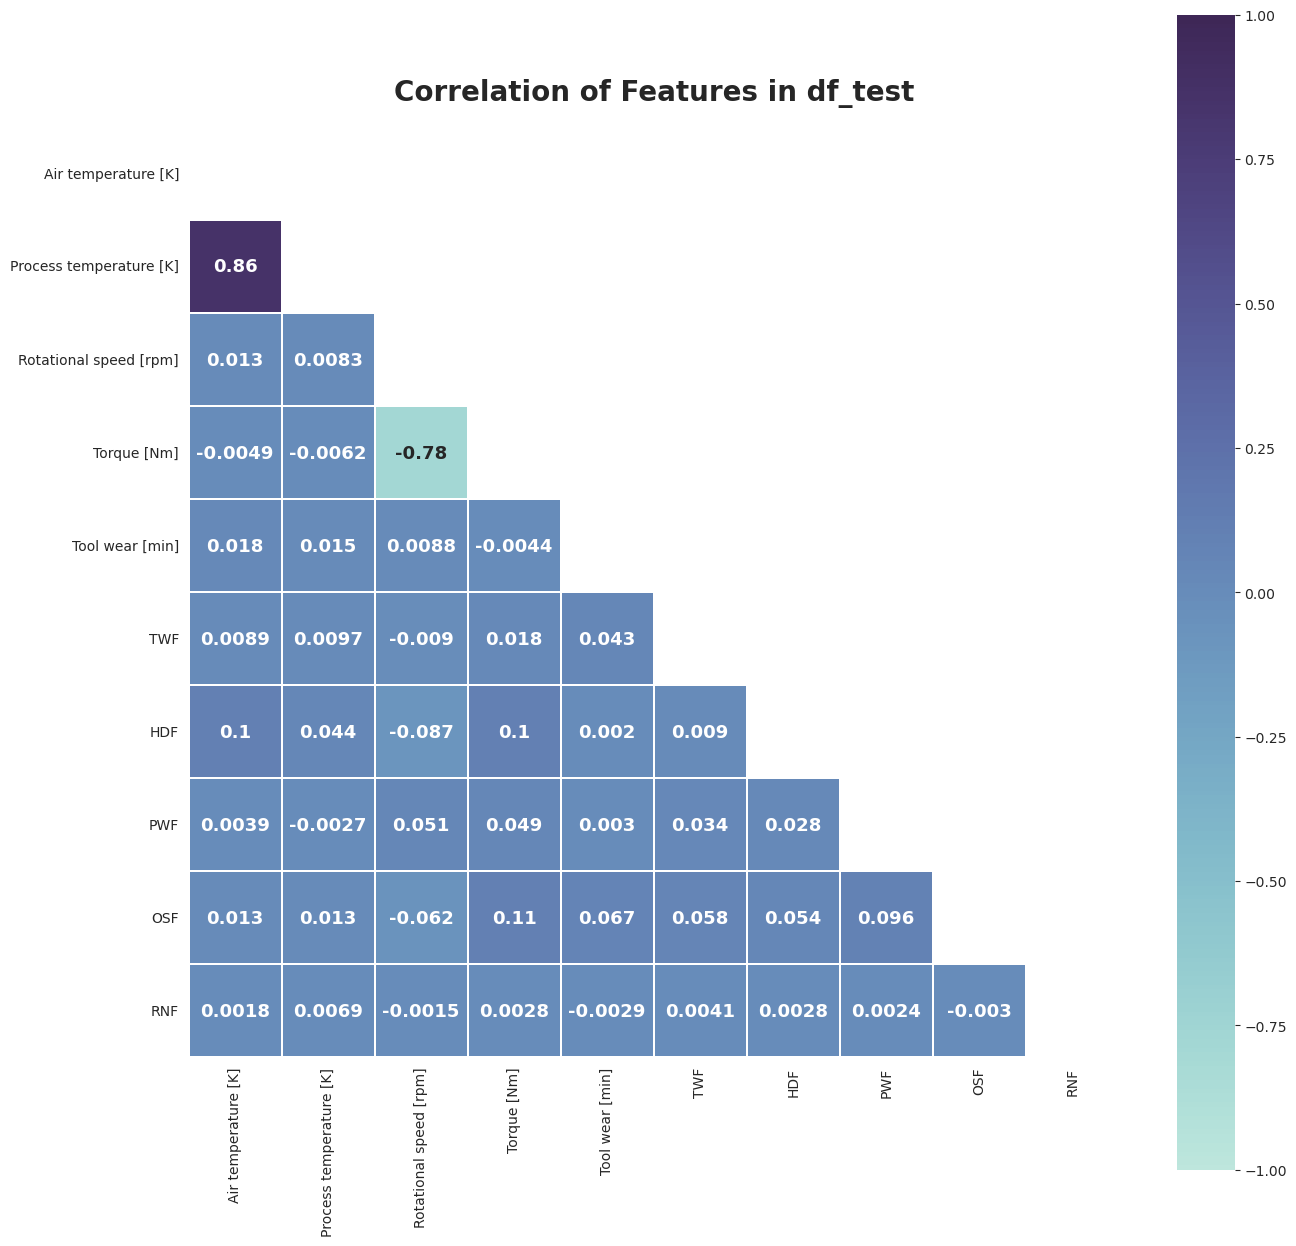

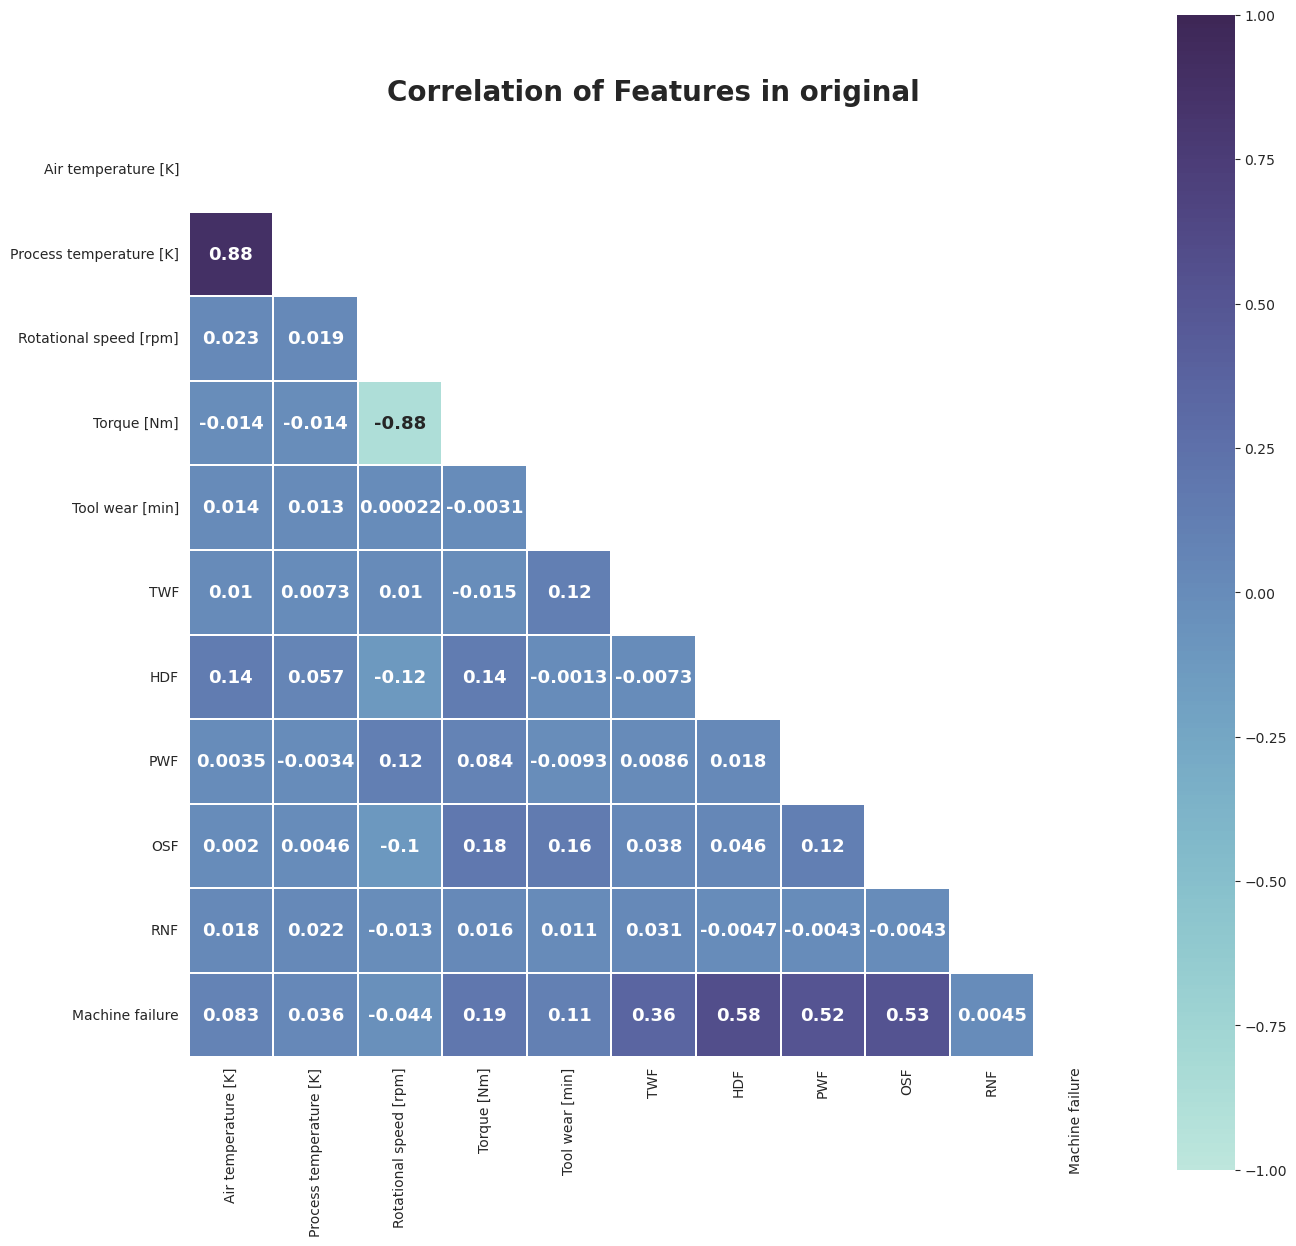

In [12]:
def plot_heatmap(df, title):
    # Create a mask for the diagonal elements
    mask = np.zeros_like(df.astype(float).corr())
    mask[np.triu_indices_from(mask)] = True

    # Set the colormap and figure size
    colormap = sns.cubehelix_palette(n_colors = 7, start=.46, rot=-.45, dark = .2, hue=0.95, as_cmap=True)
    plt.figure(figsize=(15, 15))

    # Set the title and font properties
    plt.title(f'Correlation of Features in {title}', fontweight='bold', y=1.02, size=20)

    # Plot the heatmap with the masked diagonal elements
    sns.heatmap(df.astype(float).corr(), linewidths=0.1, vmax=1.0, vmin=-1.0, 
                square=True, cmap=colormap, linecolor='white', annot=True, annot_kws={"size": 13, "weight": "bold"},
                mask=mask)

plot_heatmap(df_train[num_cols+binary_cols+[target_col]], title='df_train')
plot_heatmap(df_test[num_cols+binary_cols], title='df_test')
plot_heatmap(original[num_cols+binary_cols+[target_col]], title='original')

# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Feature Engineering </h1>

In [13]:
def conversion(df):
    df['Process temperature [K]'] = df['Process temperature [K]'] - 272.15
    df['Air temperature [K]'] = df['Air temperature [K]'] - 272.15
    
    return df

def create_features(df):
  
    # Create a new feature by divided 'Air temperature' from 'Process temperature'
    df["Temperature ratio"] = df['Process temperature [K]'] / df['Air temperature [K]']
    
    # Create a new feature by multiplying 'Torque' and 'Rotational speed'
    df['Torque * Rotational speed'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

    # Create a new feature by multiplying 'Torque' by 'Tool wear'
    df['Torque * Tool wear'] = df['Torque [Nm]'] * df['Tool wear [min]']
    
    # Create a new feature by multiplying 'Torque' by 'Rotational speed'
    df['Torque * Rotational speed'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
        
    new_cols = [ 
        'Temperature ratio', 
        'Torque * Rotational speed',
        'Torque * Tool wear',  
        'Torque * Rotational speed'
    ]
    
    return df, new_cols

def replace_Type(df):
    
    df['Type'] = df['Type'].replace({'L':0,'M':1,'H':2})
    
    return df

def cat_encoder(X_train, X_test, cat_cols, encode='label'):
    
    if encode == 'label':
        ## Label Encoder
        encoder = OrdinalEncoder(cols=cat_cols)
        train_encoder = encoder.fit_transform(X_train[cat_cols]).astype(int)
        test_encoder = encoder.transform(X_test[cat_cols]).astype(int)
        X_train[cat_cols] = train_encoder[cat_cols]
        X_test[cat_cols] = test_encoder[cat_cols]
        encoder_cols = cat_cols
    
    else:
        ## OneHot Encoder
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        train_encoder = encoder.fit_transform(X_train[cat_cols]).astype(int)
        test_encoder = encoder.transform(X_test[cat_cols]).astype(int)
        X_train = pd.concat([X_train, train_encoder], axis=1)
        X_test = pd.concat([X_test, test_encoder], axis=1)
        X_train.drop(cat_cols, axis=1, inplace=True)
        X_test.drop(cat_cols, axis=1, inplace=True)
        encoder_cols = list(train_encoder.columns)
        
    return X_train, X_test, encoder_cols

def rename_cols(df):
    df.rename(columns={"Process temperature [K]": "Process temperature C", "Air temperature [K]": "Air temperature C"}, inplace=True)
    df.columns = df.columns.str.replace('[\[\]]', '', regex=True)
    return df

In [14]:
# Concatenate train and original dataframes, and prepare train and test sets
train = pd.concat([df_train, original])
test = df_test.copy()

X_train = train.drop([f'{target_col}'],axis=1).reset_index(drop=True)
y_train = train[f'{target_col}'].reset_index(drop=True)
X_test = test.reset_index(drop=True)

# Conversion
X_train = conversion(X_train)
X_test = conversion(X_test)

# Category Encoders
X_train = replace_Type(X_train)
X_test = replace_Type(X_test)
X_train, X_test, _ = cat_encoder(X_train, X_test, ['Product ID'], encode='label')
cat_cols = ['Type', 'Product ID']

# Create Features
new_cols = []
X_train, _ = create_features(X_train)
X_test, new_cols = create_features(X_test)

# StandardScaler
sc = StandardScaler() # MinMaxScaler or StandardScaler
X_train[num_cols+new_cols] = sc.fit_transform(X_train[num_cols+new_cols])
X_test[num_cols+new_cols] = sc.transform(X_test[num_cols+new_cols])

# Drop_col
drop_cols = ['id', 'is_generated', 'RNF'] # binary_cols
X_train.drop(drop_cols, axis=1, inplace=True)
X_test.drop(drop_cols, axis=1, inplace=True)

# Rename
X_train = rename_cols(X_train)
X_test = rename_cols(X_test)

del train, test, df_train, df_test

X_train.drop(['UDI'], axis=1, inplace=True)

print(f"X_train shape :{X_train.shape} , y_train shape :{y_train.shape}")
print(f"X_test shape :{X_test.shape}")

X_train.head()

X_train shape :(146429, 14) , y_train shape :(146429,)
X_test shape :(90954, 14)


,Product ID,Type,Air temperature C,Process temperature C,Rotational speed rpm,Torque Nm,Tool wear min,TWF,HDF,PWF,OSF,Temperature ratio,Torque * Rotational speed,Torque * Tool wear
0,1,0,0.388563,-0.248148,0.524194,-0.490542,0.552766,0,0,0,0,-0.913140,-0.289927,0.300523
1,2,1,1.456753,1.547557,1.672486,-1.303478,1.491004,0,0,0,0,-0.992249,-0.961066,0.575923
2,3,0,-0.305761,-1.038258,1.996544,-1.605426,-1.245523,0,0,0,0,-0.504422,-1.311256,-1.278352
3,4,0,0.602201,0.685618,0.016972,0.461755,1.444092,0,0,0,0,-0.426430,0.743354,1.621112
4,5,1,-1.000084,-0.679117,0.841207,-0.571836,-1.104788,0,0,0,0,1.069070,-0.240255,-1.083811


# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Model Building </h1>

In [15]:
class Splitter:
    def __init__(self, n_splits=5, cat_df=pd.DataFrame(), test_size=0.5):
        self.n_splits = n_splits
        self.cat_df = cat_df
        self.test_size = test_size

    def split_data(self, X, y, random_state_list):
        for random_state in random_state_list:
            kf = KFold(n_splits=self.n_splits, random_state=random_state, shuffle=True)
            for train_index, val_index in kf.split(X, y):
                X_train, X_val = X.iloc[train_index], X.iloc[val_index]
                y_train, y_val = y.iloc[train_index], y.iloc[val_index]
                yield X_train, X_val, y_train, y_val, val_index


```python

# XGBoost 1

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'booster': trial.suggest_categorical('booster', ['gbtree']),
        'lambda': trial.suggest_float('lambda', 1e-6, 10.0),
        'alpha': trial.suggest_float('alpha', 1e-6, 10.0),
       # 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
       # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
       # 'max_depth': trial.suggest_int('max_depth', 3, 10),
       # 'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'eta': trial.suggest_float('eta', 1e-8, 1.0),
       # 'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
       # 'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
    }

    model = xgb.XGBClassifier(random_state=42, **params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'n_estimators': 1500, 'learning_rate': 0.08901459197907591, 'booster': 'gbtree', 'lambda': 8.550251116462702, 'alpha': 6.92130114930949, 'eta': 0.7719873740829137}
# Best ROC-AUC score: 0.9719218571622437

```

```python
# XGBoost 2

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'booster': trial.suggest_categorical('booster', ['gbtree']),
        'lambda': trial.suggest_float('lambda', 1e-8, .1),
        'alpha': trial.suggest_float('alpha', 1e-8, .1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'eta': trial.suggest_float('eta', 1e-8, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),

    }

    model = xgb.XGBClassifier(random_state=42, **params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'n_estimators': 550, 'learning_rate': 0.014551680348136895, 'booster': 'gbtree', 'lambda': 0.028738149876528587, 'alpha': 0.014056635017117198, 'subsample': 0.538653498449084, 'colsample_bytree': 0.518050828371974, 'max_depth': 4, 'min_child_weight': 4, 'eta': 0.6953619445477833, 'gamma': 0.9036568111424781}
# Best ROC-AUC score: 0.9747951638803715
```

```python

# Cat 1

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-6, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'border_count': trial.suggest_int('border_count', 1, 255),
        'random_state': 42,
    }

    model = CatBoostClassifier(**params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold, verbose=False)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'iterations': 600, 'learning_rate': 0.019499308200732167, 'depth': 8, 'l2_leaf_reg': 9.024309909697191, 'bagging_temperature': 7.9669359481998825, 'random_strength': 5.293875378529096, 'border_count': 235}
# Best ROC-AUC score: 0.9734008776040477
```

```python

# Cat 2

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-6, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'random_state': 42,
    }

    model = CatBoostClassifier(**params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold, verbose=False)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'iterations': 1000, 'learning_rate': 0.013171032440433215, 'depth': 5, 'l2_leaf_reg': 2.805405544410651, 'bagging_temperature': 5.869195302151575, 'random_strength': 9.103415468292203}
# Best ROC-AUC score: 0.9742089488622947
```

```python

# LGBM 1

def objective(trial):
    params = {
        'num_iterations': trial.suggest_int('num_iterations', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'lambda': trial.suggest_float('lambda', 1e-6, 10.0),
        'alpha': trial.suggest_float('alpha', 1e-6, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'random_state': 42,
    }

    model = lgb.LGBMClassifier(**params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold, verbose=False)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'num_iterations': 200, 'learning_rate': 0.024714536811915398, 'max_depth': 9, 'lambda': 9.498413255934212, 'alpha': 7.627590925937886, 'subsample': 0.9680186598781285, 'colsample_bytree': 0.5645599877042381, 'min_child_weight': 1}
# Best ROC-AUC score: 0.9800713152506126
```

```python

# LGBM 2

def objective(trial):
    params = {
        'num_iterations': trial.suggest_int('num_iterations', 500, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'lambda': trial.suggest_float('lambda', 1e-6, 10.0),
        'alpha': trial.suggest_float('alpha', 1e-6, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'random_state': 42,
    }

    model = lgb.LGBMClassifier(**params)
    
    # Perform k-fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model.fit(X_train_fold, y_train_fold, verbose=False)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_val_pred)
        scores.append(score)
    
    avg_score = sum(scores) / len(scores)

    return avg_score

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

best_params = study.best_params
best_score = study.best_value

print("Best params:", best_params)
print("Best ROC-AUC score:", best_score)

# Best params: {'num_iterations': 950, 'learning_rate': 0.012019976156417951, 'max_depth': 4, 'lambda': 6.958643473661789, 'alpha': 0.0012598800466591953, 'subsample': 0.9344619448867001, 'colsample_bytree': 0.9864399750557648, 'min_child_weight': 1}
# Best ROC-AUC score: 0.9765868659115547
```

In [16]:
class Classifier:
    def __init__(self, n_estimators=100, device="cpu", random_state=42):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.models = self.get_models()
        self.models_name = list(self.get_models().keys())
        self.len_models = len(self.models)
        
    def get_models(self):
        
        xgb_optuna1 = {
            'n_estimators': 1500,
            'learning_rate': 0.08901459197907591,
            'booster': 'gbtree',
            'lambda': 8.550251116462702,
            'alpha': 6.92130114930949,
            'eta': 0.7719873740829137,
            'grow_policy': 'lossguide',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            'verbosity': 0,
            'random_state': self.random_state
        }
        
        xgb_optuna2 = {
            'n_estimators': 550,
            'learning_rate': 0.014551680348136895,
            'booster': 'gbtree',
            'lambda': 0.028738149876528587,
            'alpha': 0.014056635017117198,
            'subsample': 0.538653498449084,
            'colsample_bytree': 0.518050828371974, 
            'max_depth': 4, 'min_child_weight': 4,
            'eta': 0.6953619445477833,
            'gamma': 0.9036568111424781,
            'grow_policy': 'lossguide',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            'verbosity': 0,
            'random_state': self.random_state
        }
        
        xgb1_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.0503196477566407,
            'booster': 'gbtree',
            'lambda': 0.00379319640405843,
            'alpha': 0.106754104302093,
            'subsample': 0.938028434508189,
            'colsample_bytree': 0.212545425027345,
            'max_depth': 9,
            'min_child_weight': 2,
            'eta': 1.03662446190642E-07,
            'gamma': 0.000063826049787043,
            'grow_policy': 'lossguide',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            #'eval_metric': 'auc',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        xgb2_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.00282353606391198,
            'booster': 'gbtree',
            'lambda': 0.399776698351379,
            'alpha': 1.01836149061356E-07,
            'subsample': 0.957123754766769,
            'colsample_bytree': 0.229857555596548,
            'max_depth': 9,
            'min_child_weight': 4,
            'eta': 2.10637756839133E-07,
            'gamma': 0.00314857715085414,
            'grow_policy': 'depthwise',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            #'eval_metric': 'auc',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        xgb3_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.00349356650247156,
            'booster': 'gbtree',
            'lambda': 0.0002963239871324443,
            'alpha': 0.0000162103492458353,
            'subsample': 0.822994064549709,
            'colsample_bytree': 0.244618079894501,
            'max_depth': 10,
            'min_child_weight': 2,
            'eta': 8.03406601824666E-06,
            'gamma': 3.91180893163099E-07,
            'grow_policy': 'depthwise',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            #'eval_metric': 'auc',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        
        lgb_optuna1 = {
            'num_iterations': 200,
            'learning_rate': 0.024714536811915398,
            'max_depth': 9,
            'lambda': 9.498413255934212,
            'alpha': 7.627590925937886,
            'subsample': 0.9680186598781285,
            'colsample_bytree': 0.5645599877042381,
            'min_child_weight': 1,
            'device': self.device,
            'random_state': self.random_state
        }
        
        lgb_optuna2 = {
            'num_iterations': 950,
            'learning_rate': 0.012019976156417951,
            'max_depth': 4,
            'lambda': 6.958643473661789,
            'alpha': 0.0012598800466591953, 
            'subsample': 0.9344619448867001,
            'colsample_bytree': 0.9864399750557648, 
            'min_child_weight': 1,
            'device': self.device,
            'random_state': self.random_state
        }
        
        lgb1_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.0124415817896377,
            'reg_alpha': 0.00139174509988134,
            'reg_lambda': 0.000178964551019674,
            'num_leaves': 249,
            'colsample_bytree': 0.675264038614975,
            'subsample': 0.421482143660471,
            'subsample_freq': 4,
            'min_child_samples': 8,
            'objective': 'binary',
            'metric': 'binary_error',
            'boosting_type': 'gbdt',
            'is_unbalance':True,
            # 'n_jobs': -1,
            #'force_row_wise': True,
            'device': self.device,
            'random_state': self.random_state
        }
        lgb2_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.0247403801218241,
            'reg_alpha': 6.84813726047269E-06,
            'reg_lambda': 3.40443691552308E-08,
            'num_leaves': 223,
            'colsample_bytree': 0.597332047776164,
            'subsample': 0.466442641250326,
            'subsample_freq': 2,
            'min_child_samples': 5,
            'objective': 'binary',
            'metric': 'binary_error',
            'boosting_type': 'gbdt',
            'is_unbalance':True,
            # 'n_jobs': -1,
            #'force_row_wise': True,
            'device': self.device,
            'random_state': self.random_state
        }
        lgb3_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.0109757020463629,
            'reg_alpha': 0.174927073496136,
            'reg_lambda': 2.45325882544558E-07,
            'num_leaves': 235,
            'colsample_bytree': 0.756605772162953,
            'subsample': 0.703911560320816,
            'subsample_freq': 5,
            'min_child_samples': 21,
            'objective': 'binary',
            'metric': 'binary_error',
            'boosting_type': 'gbdt',
            'is_unbalance':True,
            # 'n_jobs': -1,
            #'force_row_wise': True,
            'device': self.device,
            'random_state': self.random_state
        }
        
        cat_optuna1 = {
            'iterations': 600,
            'learning_rate': 0.019499308200732167,
            'depth': 8,
            'l2_leaf_reg': 9.024309909697191,
            'bagging_temperature': 7.9669359481998825,
            'random_strength': 5.293875378529096,
            'border_count': 235,
            'auto_class_weights': 'Balanced',
            'task_type': self.device.upper(),
            'verbose': False,
            'allow_writing_files': False,
            'random_state': self.random_state
        }
        
        cat_optuna2 = {
            'iterations': 1000,
            'learning_rate': 0.013171032440433215,
            'depth': 5, 
            'l2_leaf_reg': 2.805405544410651,
            'bagging_temperature': 5.869195302151575,
            'random_strength': 9.103415468292203,
            'task_type': self.device.upper(),
            'verbose': False,
            'allow_writing_files': False,
            'random_state': self.random_state
        }
        
        cat1_params = {
            'iterations': self.n_estimators,
            'depth': 3,
            'learning_rate': 0.020258010893459,
            'l2_leaf_reg': 0.583685138705941,
            'random_strength': 0.177768021213223,
            'od_type': "Iter", 
            'od_wait': 116,
            'bootstrap_type': "Bayesian",
            'grow_policy': 'Depthwise',
            'bagging_temperature': 0.478048798393903,
            'eval_metric': 'Logloss', # AUC
            'loss_function': 'Logloss',
            'auto_class_weights': 'Balanced',
            'task_type': self.device.upper(),
            'verbose': False,
            'allow_writing_files': False,
            'random_state': self.random_state
        }
        cat2_params = {
            'iterations': self.n_estimators,
            'depth': 5,
            'learning_rate': 0.00666304601039438,
            'l2_leaf_reg': 0.0567881687170355,
            'random_strength': 0.00564702921370138,
            'od_type': "Iter", 
            'od_wait': 93,
            'bootstrap_type': "Bayesian",
            'grow_policy': 'Depthwise',
            'bagging_temperature': 2.48298505165348,
            'eval_metric': 'Logloss', # AUC
            'loss_function': 'Logloss',
            'auto_class_weights': 'Balanced',
            'task_type': self.device.upper(),
            'verbose': False,
            'allow_writing_files': False,
            'random_state': self.random_state
        }
        cat3_params = {
            'iterations': self.n_estimators,
            'depth': 5,
            'learning_rate': 0.0135730417743519,
            'l2_leaf_reg': 0.0597353604503262,
            'random_strength': 0.0675876600077264,
            'od_type': "Iter", 
            'od_wait': 122,
            'bootstrap_type': "Bayesian",
            'grow_policy': 'Depthwise',
            'bagging_temperature': 1.85898154006468,
            'eval_metric': 'Logloss', # AUC
            'loss_function': 'Logloss',
            'auto_class_weights': 'Balanced',
            'task_type': self.device.upper(),
            'verbose': False,
            'allow_writing_files': False,
            'random_state': self.random_state
        }
        
        models = {
            "xgbo1": xgb.XGBClassifier(**xgb_optuna1),
            "xgbo2": xgb.XGBClassifier(**xgb_optuna2),
            "xgb1": xgb.XGBClassifier(**xgb1_params),
            "xgb2": xgb.XGBClassifier(**xgb2_params),
            "xgb3": xgb.XGBClassifier(**xgb3_params),
            "lgbo1": lgb.LGBMClassifier(**lgb_optuna1),
            "lgbo2": lgb.LGBMClassifier(**lgb_optuna2),
            #"lgb1": lgb.LGBMClassifier(**lgb1_params),
            #"lgb2": lgb.LGBMClassifier(**lgb2_params),
            #"lgb3": lgb.LGBMClassifier(**lgb3_params),
            "cato1": CatBoostClassifier(**cat_optuna1),
            "cato2": CatBoostClassifier(**cat_optuna2),
            #"cat1": CatBoostClassifier(**cat1_params),
            #"cat2": CatBoostClassifier(**cat2_params),
           # "cat3": CatBoostClassifier(**cat3_params),
            #'rf': RandomForestClassifier(n_estimators=500, n_jobs=-1, class_weight="balanced", random_state=self.random_state),
            #'lr': LogisticRegressionCV(max_iter=2000, random_state=self.random_state)
        }
        return models

In [17]:
class OptunaWeights:
    def __init__(self, random_state, n_trials=100):
        self.study = None
        self.weights = None
        self.random_state = random_state
        self.n_trials = n_trials

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 1e-15, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the score for the weighted prediction
        score = roc_auc_score(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        pruner = optuna.pruners.HyperbandPruner()
        self.study = optuna.create_study(sampler=sampler, pruner=pruner, study_name="OptunaWeights", direction='maximize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=self.n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds):
        self.fit(y_true, y_preds)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights

# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Model Training</h1>

In [18]:
# Config
n_splits = 10
random_state = 42
random_state_list =[42]
n_estimators = 100
device = 'cpu'
early_stopping_rounds = 444
verbose = False

# Split Data
splitter = Splitter(n_splits=n_splits, cat_df= y_train)
splits = splitter.split_data(X_train, y_train, random_state_list=random_state_list)

# Initialize an array for storing test predictions
classifier = Classifier(n_estimators=n_estimators, device=device, random_state=random_state)
test_predss = np.zeros((X_test.shape[0]))
oof_predss = np.zeros((X_train.shape[0]))
ensemble_score = []
weights = []
models_name = [_ for _ in classifier.models_name if ('xgb' in _) or ('lgb' in _) or ('cat' in _)]
trained_models = dict(zip(models_name, [[] for _ in range(classifier.len_models)]))
score_dict = dict(zip(classifier.models_name, [[] for _ in range(len(classifier.models_name))]))

for i, (X_train_, X_val, y_train_, y_val, val_index) in enumerate(splits):
    
    n = i % n_splits
    m = i // n_splits
    

    # Classifier models
    classifier = Classifier(n_estimators, device, random_state)
    models = classifier.models

    # Store oof and test predictions for each base model
    oof_preds = []
    test_preds = []

    # Loop over each base model and fit it
    for name, model in models.items():
        if ('xgb' in name) or ('lgb' in name):
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
            
        elif 'cat' in name :
                model.fit(
                    Pool(X_train_, y_train_, cat_features=cat_cols), eval_set=Pool(X_val, y_val, cat_features=cat_cols),
                    early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        else:
            model.fit(X_train_, y_train_)
            
        if name in trained_models.keys():
            trained_models[f'{name}'].append(deepcopy(model))

        test_pred = model.predict_proba(X_test)[:, 1]
        y_val_pred = model.predict_proba(X_val)[:, 1]

        score = roc_auc_score(y_val, y_val_pred)
        score_dict[name].append(score)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] ROC-AUC score: {score:.5f}')

        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)

    # Use OptunaWeights
    optweights = OptunaWeights(random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)

    score = roc_auc_score(y_val, y_val_pred)
    print(f'Ensemble [FOLD-{n} SEED-{random_state_list[m]}] ROC-AUC score {score:.5f} \n')
    ensemble_score.append(score)
    weights.append(optweights.weights)

    # Predict to X_test by the best ensemble weights
    test_predss += optweights.predict(test_preds) / (n_splits * len(random_state_list))
    oof_predss[X_val.index] = optweights.predict(oof_preds)

    gc.collect()

xgbo1 [FOLD-0 SEED-42] ROC-AUC score: 0.97044
xgbo2 [FOLD-0 SEED-42] ROC-AUC score: 0.96850
xgb1 [FOLD-0 SEED-42] ROC-AUC score: 0.97449
xgb2 [FOLD-0 SEED-42] ROC-AUC score: 0.96785
xgb3 [FOLD-0 SEED-42] ROC-AUC score: 0.97697
[LightGBM] [Warning] lambda_l2 is set with lambda=9.498413255934212, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.498413255934212
lgbo1 [FOLD-0 SEED-42] ROC-AUC score: 0.97088
[LightGBM] [Warning] lambda_l2 is set with lambda=6.958643473661789, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.958643473661789
lgbo2 [FOLD-0 SEED-42] ROC-AUC score: 0.96916
cato1 [FOLD-0 SEED-42] ROC-AUC score: 0.97980
cato2 [FOLD-0 SEED-42] ROC-AUC score: 0.98095
Ensemble [FOLD-0 SEED-42] ROC-AUC score 0.98009 

xgbo1 [FOLD-1 SEED-42] ROC-AUC score: 0.96599
xgbo2 [FOLD-1 SEED-42] ROC-AUC score: 0.96482
xgb1 [FOLD-1 SEED-42] ROC-AUC score: 0.96499
xgb2 [FOLD-1 SEED-42] ROC-AUC score: 0.95879
xgb3 [FOLD-1 SEED-42] ROC-AUC score: 0.96756
[LightGBM] [Warning] lam

In [19]:
# Calculate the mean score of the ensemble
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Mean Optuna Ensemble {mean_score:.5f} ± {std_score:.5f} \n')

print('--- Optuna Weights---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name}: {mean_weight:.5f} ± {std_weight:.5f}')


Mean Optuna Ensemble 0.98144 ± 0.00597 

--- Optuna Weights---
xgbo1: 0.32269 ± 0.26216
xgbo2: 0.32608 ± 0.26508
xgb1: 0.49814 ± 0.35499
xgb2: 0.35016 ± 0.25044
xgb3: 0.42009 ± 0.24513
lgbo1: 0.35251 ± 0.31537
lgbo2: 0.21905 ± 0.15487
cato1: 0.38750 ± 0.26474
cato2: 0.77329 ± 0.13890


# <h1 style = "font-family: Georgia;font-weight: bold; font-size: 30px; color: #1192AA; text-align:left">Submission</h1>

In [20]:
sample_submission[f'{target_col}'] = test_predss
sample_submission.to_csv(f'submission.csv', index=False)
sample_submission

,id,Machine failure
0,136429,0.080479
1,136430,0.082924
2,136431,0.079257
3,136432,0.082732
4,136433,0.080603
...,...,...
90949,227378,0.082092
90950,227379,0.087521
90951,227380,0.082853
90952,227381,0.093714
